In [4]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import OneHotEncoder

# 加载数据
df = pd.DataFrame(pd.read_csv("../Data/watermelon3.0.csv", encoding="ansi"))
df.drop(labels=["编号"], axis=1, inplace=True)  # 删除编号这一列，inplace=True表示直接在原对象修改
features = ['色泽', '根蒂', '敲声', '纹理', '脐部', '触感', '密度', '含糖量']
# 提取特征和标签
X = df.iloc[:,:-1].values
y = df.iloc[:,-1].values
# 转码
X = pd.DataFrame(X, columns=features)
# 独热编码
X_encoded = pd.get_dummies(X,columns = ["色泽","根蒂","敲声","纹理","脐部","触感"])
new_features = list(X_encoded.columns)
X_encoded = np.array(X_encoded, dtype=np.float64)
# 标签数值化
for i in range(len(y)):
    if y[i] == '是':
        y[i] = 1
    else:
        y[i] = 0
y_encoded = np.array(y, dtype=np.int64).reshape(-1,1) # 转为列向量
# 拼接特征和标签
dataset = np.concatenate((X_encoded, y_encoded), axis=1)
print(dataset.shape)   

(17, 20)


In [5]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

# 加载数据集
iris = load_iris()
X = iris.data
y = iris.target
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=42)

y_train = pd.get_dummies(y_train).values
y_train = np.array(y_train, dtype=int)
y_test = pd.get_dummies(y_test).values
y_test = np.array(y_test, dtype=int)

Epoch: 10000 
Loss: 1.3841672802481364


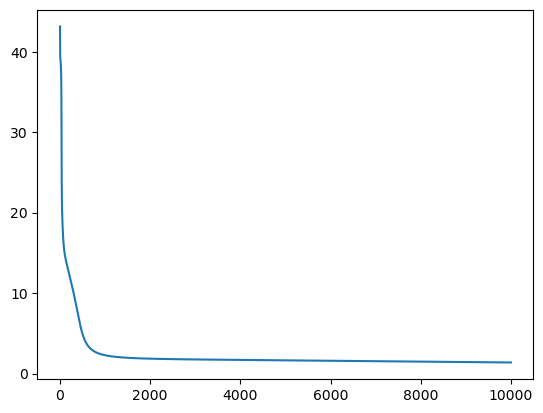

Epoch: 10000 
Loss: 1.7235632349701624


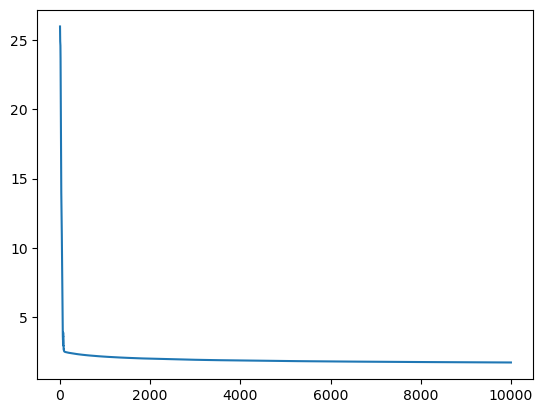

In [ ]:
class Net_BP():
    def __init__(self, input_size = 19, hidden_size = 10, output_size = 1, lr = 0.1):
        """
        BP神经网络
        
        参数:
        input_size: 输入层大小
        hidden_size: 隐含层大小
        output_size: 输出层大小
        method: 训练方法，'standard_BP'表示标准BP算法，'accumulate_BP'表示累积BP算法
        lr: 学习率
        """
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.output_size = output_size
        self.lr = lr
        # 输入与隐含层之间的连接权和阈值
        self.w1 = np.random.randn(input_size, hidden_size)
        self.b1 = np.random.randn(1, hidden_size)
        # 隐含层与输出层之间的连接权和阈值
        self.w2 = np.random.randn(hidden_size, output_size)
        self.b2 = np.random.randn(1, output_size)


    def sigmoid(self,z):
        """激活函数"""
        return 1.0 / (1.0 + np.exp(-z))
    
    def standard_BP(self,X,y):
        """标准BP算法"""
        loss = 1
        all_loss = []
        epoch = 0
        while epoch < 10000 and loss > 0.001:
            for i in range(X.shape[0]):
                # 前向传播
                b = self.sigmoid(X[i] @ self.w1 - self.b1) # 隐含层输出(1 × hidden_size)
                y_pred = self.sigmoid(b @ self.w2 - self.b2) # 输出层输出(1 × output_size)
                # 反向传播
                # 公式(5,10)
                g = y_pred * (1 - y_pred) * (y[i] - y_pred) # (1 × output_size)
                # 公式(5,15)
                e = b * (1 - b) * (g @ self.w2.T) # (1 × hidden_size)
                # 更新参数
                self.w2 += self.lr * (b.T @ g) # (hidden_size × output_size)
                self.b2 -= self.lr * g # (1 × output_size)
                self.w1 += self.lr * (X[i].reshape(-1,1) @ e) # (input_size × hidden_size)
                self.b1 -= self.lr * e # (1 × hidden_size)
            # 计算损失
            loss = self.calulate_loss(X,y)
            all_loss.append(loss)
            epoch += 1
        print('Epoch:', epoch,'\nLoss:', loss)
        # 绘制损失变化图
        plt.plot(all_loss)
        plt.show()

    def predict(self,X):
        """预测"""
        b = self.sigmoid(X @ self.w1 - self.b1) # 隐含层输出(1 × hidden_size)
        y_pred = self.sigmoid(b @ self.w2 - self.b2) # 输出层输出(1 × output_size)
        return y_pred
    
    def calulate_loss(self,X,y):
        """计算损失"""
        loss = 0
        loss = (1/2) * np.sum((y - self.predict(X))**2)
        return loss
    
    

if __name__ == '__main__':
    BP_Std = Net_BP(input_size=4, hidden_size=5, output_size=3, lr=0.02)
    BP_Std.standard_BP(x_train,y_train)

    BP_Std_Plus = Net_BP(input_size=4, hidden_size=5, output_size=3, lr=0.1)
    BP_Std_Plus.standard_BP_Plus(x_train,y_train)
                

    
    
        

Epoch: 0, Loss: 23.592087, LR: 0.010000
Epoch: 100, Loss: 2.202586, LR: 0.010000
Epoch: 200, Loss: 1.955206, LR: 0.010000
Epoch: 300, Loss: 1.854928, LR: 0.010000
Epoch: 400, Loss: 1.810382, LR: 0.010000
Epoch: 500, Loss: 1.791488, LR: 0.010000
Epoch: 600, Loss: 1.771040, LR: 0.010000
Epoch: 700, Loss: 1.739227, LR: 0.010000
Epoch: 800, Loss: 1.728756, LR: 0.010000
Epoch: 900, Loss: 1.731622, LR: 0.010000
Epoch: 1000, Loss: 1.743217, LR: 0.010000
Epoch: 1100, Loss: 1.754663, LR: 0.010000
Epoch: 1200, Loss: 1.753116, LR: 0.010000
Epoch: 1300, Loss: 1.737976, LR: 0.010000
Epoch: 1400, Loss: 1.728480, LR: 0.010000
Epoch: 1500, Loss: 1.758637, LR: 0.010000
Epoch: 1600, Loss: 1.715572, LR: 0.010000
Epoch: 1700, Loss: 1.599114, LR: 0.010000
Epoch: 1800, Loss: 1.646559, LR: 0.010000
Epoch: 1900, Loss: 1.568729, LR: 0.010000
Epoch: 2000, Loss: 1.480889, LR: 0.010000
Epoch: 2100, Loss: 1.391090, LR: 0.010000
Epoch: 2200, Loss: 1.303824, LR: 0.010000
Epoch: 2300, Loss: 1.217420, LR: 0.010000
Epo

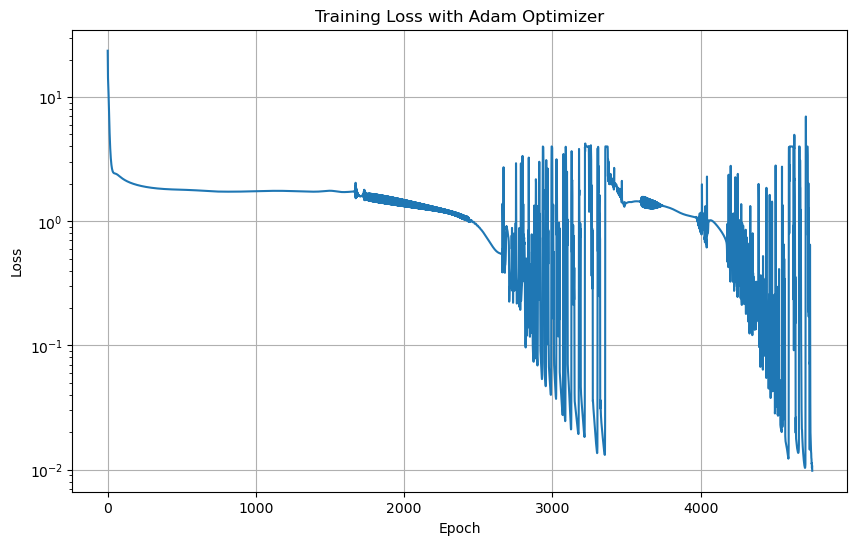

In [7]:
import numpy as np
import matplotlib.pyplot as plt

class Net_BP_Adam():
    def __init__(self, input_size=19, hidden_size=10, output_size=1, 
                 lr=0.001, beta1=0.9, beta2=0.999, epsilon=1e-8):
        """
        BP神经网络（使用Adam优化算法）
        
        参数:
        input_size: 输入层大小
        hidden_size: 隐含层大小
        output_size: 输出层大小
        lr: 学习率
        beta1, beta2: Adam算法的衰减率参数
        epsilon: 防止除以零的小常数
        """
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.output_size = output_size
        self.lr = lr
        self.beta1 = beta1
        self.beta2 = beta2
        self.epsilon = epsilon
        
        # 初始化参数
        self.w1 = np.random.randn(input_size, hidden_size) * 0.1
        self.b1 = np.random.randn(1, hidden_size) * 0.1
        self.w2 = np.random.randn(hidden_size, output_size) * 0.1
        self.b2 = np.random.randn(1, output_size) * 0.1
        
        # 初始化Adam状态变量
        self.m_w1 = np.zeros_like(self.w1)
        self.v_w1 = np.zeros_like(self.w1)
        self.m_b1 = np.zeros_like(self.b1)
        self.v_b1 = np.zeros_like(self.b1)
        
        self.m_w2 = np.zeros_like(self.w2)
        self.v_w2 = np.zeros_like(self.w2)
        self.m_b2 = np.zeros_like(self.b2)
        self.v_b2 = np.zeros_like(self.b2)
        
        # 时间步计数
        self.t = 0

    def sigmoid(self, z):
        """Sigmoid激活函数"""
        return 1.0 / (1.0 + np.exp(-np.clip(z, -500, 500)))  # 添加数值稳定处理

    def adam_update(self, gradients, m_prev, v_prev):
        """
        执行Adam参数更新
        """
        self.t += 1  # 更新步数计数器
        
        # 更新一阶矩估计（加入动量）
        m = self.beta1 * m_prev + (1 - self.beta1) * gradients
        
        # 更新二阶矩估计（RMSProp）
        v = self.beta2 * v_prev + (1 - self.beta2) * (gradients ** 2)
        
        # 偏差修正
        m_hat = m / (1 - self.beta1 ** self.t)
        v_hat = v / (1 - self.beta2 ** self.t)
        
        # 参数更新
        param_update = self.lr * m_hat / (np.sqrt(v_hat) + self.epsilon)
        
        return m, v, param_update

    def standard_BP_Adam(self, X, y, max_epochs=10000, min_loss=0.001):
        """
        使用Adam优化算法的标准BP算法
        
        参数:
        X: 训练数据 (n_samples, input_size)
        y: 标签数据 (n_samples, output_size)
        max_epochs: 最大训练轮数
        min_loss: 最小损失阈值
        """
        losses = []
        epoch = 0
        current_loss = float('inf')
        
        while epoch < max_epochs and current_loss > min_loss:
            epoch_loss = 0
            
            for i in range(X.shape[0]):
                # 前向传播
                input_layer = X[i] @ self.w1 - self.b1
                hidden_out = self.sigmoid(input_layer)  # (1, hidden_size)
                
                output_layer = hidden_out @ self.w2 - self.b2
                y_pred = self.sigmoid(output_layer)  # (1, output_size)
                
                # 计算误差
                error = y[i] - y_pred
                epoch_loss += 0.5 * np.sum(error ** 2)
                
                # 反向传播计算梯度
                # 输出层梯度
                g = y_pred * (1 - y_pred) * error  # (1, output_size)
                
                # 隐藏层梯度
                e = hidden_out * (1 - hidden_out) * (g @ self.w2.T)  # (1, hidden_size)
                
                # 计算各层参数的梯度
                grad_w2 = hidden_out.T @ g  # (hidden_size, output_size)
                grad_b2 = -g  # (1, output_size)
                grad_w1 = X[i].reshape(-1, 1) @ e  # (input_size, hidden_size)
                grad_b1 = -e  # (1, hidden_size)
                
                # 使用Adam更新W2和b2
                self.m_w2, self.v_w2, w2_update = self.adam_update(grad_w2, self.m_w2, self.v_w2)
                self.m_b2, self.v_b2, b2_update = self.adam_update(grad_b2, self.m_b2, self.v_b2)
                
                # 使用Adam更新W1和b1
                self.m_w1, self.v_w1, w1_update = self.adam_update(grad_w1, self.m_w1, self.v_w1)
                self.m_b1, self.v_b1, b1_update = self.adam_update(grad_b1, self.m_b1, self.v_b1)
                
                # 应用参数更新
                self.w2 += w2_update
                self.b2 += b2_update
                self.w1 += w1_update
                self.b1 += b1_update
            
            # 记录损失
            current_loss = self.calulate_loss(X, y)
            losses.append(current_loss)
            
            # 每100轮打印一次进度
            if epoch % 100 == 0:
                print(f'Epoch: {epoch}, Loss: {current_loss:.6f}, LR: {self.lr:.6f}')
            
            epoch += 1
        
        print(f'Training completed at Epoch: {epoch}')
        print(f'Final Loss: {current_loss:.6f}')
        
        # 绘制损失变化图
        plt.figure(figsize=(10, 6))
        plt.plot(losses)
        plt.title('Training Loss with Adam Optimizer')
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.yscale('log')  # 对数坐标更清晰
        plt.grid(True)
        plt.show()
        
        return losses

    def predict(self, X):
        """预测"""
        hidden_out = self.sigmoid(X @ self.w1 - self.b1)
        y_pred = self.sigmoid(hidden_out @ self.w2 - self.b2)
        return y_pred
    
    def calulate_loss(self,X,y):
        """计算损失"""
        loss = 0
        loss = (1/2) * np.sum((y - self.predict(X))**2)
        return loss

if __name__ == '__main__':
    # 创建并训练BP神经网络（使用Adam）
    bp_adam = Net_BP_Adam(input_size=4, hidden_size=5, output_size=3, lr=0.01)
    bp_adam.standard_BP_Adam(x_train, y_train, min_loss=0.01)
    